# 1. Zip Puzzle Input

In [ ]:
from dataclasses import dataclass, field
from typing import Optional

@dataclass(frozen=True)
class Cell:
    row: int
    col: int

@dataclass
class Grid:
    rows: int
    cols: int
    # None = empty cell, int = numbered waypoint
    cells: list[list[Optional[int]]]
    # Sorted list of (number, Cell) - derived once at load time
    waypoints: list[tuple[int, Cell]] = field(default_factory=list)

    def __post_init__(self):
        for r in range(self.rows):
            for c in range(self.cols):
                v = self.cells[r][c]
                if v is not None:
                    self.waypoints.append((v, Cell(r, c)))
        self.waypoints.sort()

    def get(self, cell: Cell) -> Optional[int]:
        return self.cells[cell.row][cell.col]

@dataclass(frozen=True)
class State:
    current: Cell # where the path head is right now
    path: tuple[Cell, ...] # full path from start, as an immutable tuple
    visited: frozenset # O(1) membership checks - critical for performance
    next_waypoint_idx: int # index into grid.waypoints - which number to hit next

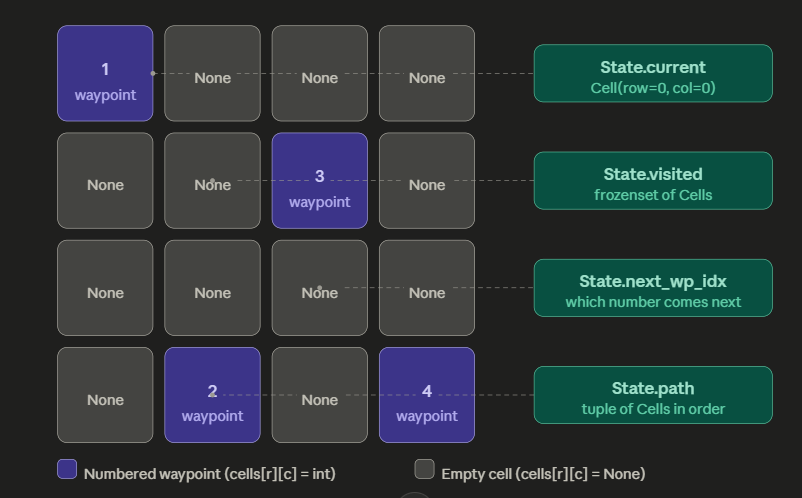

In [ ]:
puzzle = [
    [1,    None, None, None],
    [None, None, 3,    None],
    [None, None, None, None],
    [None, 2,    None, 4   ],
]
grid = Grid(rows=4, cols=4, cells=puzzle)

# Initial state - start at waypoint 1's position
start_cell = grid.waypoints[0][1]
initial_state = State(
    current=start_cell,
    path=(start_cell,),
    visited=frozenset([start_cell]),
    next_waypoint_idx=1,
)

# 2. State-space representation

In [ ]:
def get_neighbors(cell: Cell, grid: Grid) -> list[Cell]:
    """4-directional adjacency — change to 8 if the game allows diagonals."""
    directions = [(-1,0),(1,0),(0,-1),(0,1)]
    return [
        Cell(cell.row + dr, cell.col + dc)
        for dr, dc in directions
        if 0 <= cell.row + dr < grid.rows
        and 0 <= cell.col + dc < grid.cols
    ]

def get_successors(state: State, grid: Grid) -> list[State]:
    """Generate all legal next states from the current state."""
    successors = []
    for neighbor in get_neighbors(state.current, grid):
        # Constraint 1: never revisit a cell
        if neighbor in state.visited:
            continue
        # Constraint 2: if neighbor is a numbered cell, it must be the NEXT number
        cell_value = grid.get(neighbor)
        if cell_value is not None:
            expected = grid.waypoints[state.next_waypoint_idx][0]
            if cell_value != expected:
                continue  # wrong waypoint - skip
        # Build the new state (immutable - share grid, copy only what changes)
        new_idx = state.next_waypoint_idx + (1 if cell_value is not None else 0)
        successors.append(State(
            current=neighbor,
            path=state.path + (neighbor,),
            visited=state.visited | {neighbor},
            next_waypoint_idx=new_idx,
        ))
    return successors

def is_goal(state: State, grid: Grid) -> bool:
    """Solved when all waypoints visited AND every cell is covered."""
    all_waypoints_done = state.next_waypoint_idx == len(grid.waypoints)
    all_cells_covered = len(state.visited) == grid.rows * grid.cols
    return all_waypoints_done and all_cells_covered

# 3. Constraint Filtering (legal move generator)

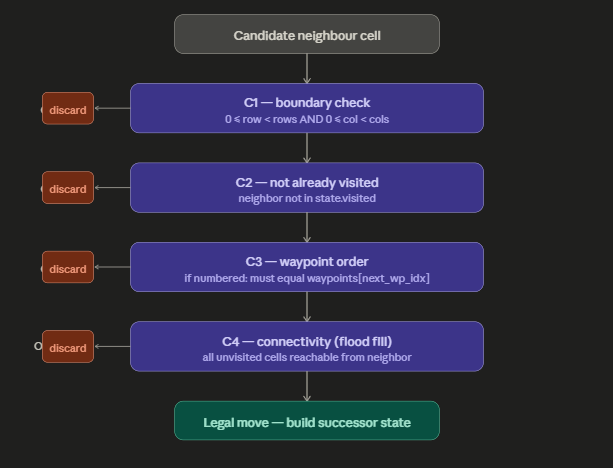

In [ ]:
from collections import deque   

def get_successors(state: State, grid: Grid) -> list[State]:
    successors = []
    for dr, dc in [(-1,0),(1,0),(0,-1),(0,1)]:
        nr, nc = state.current.row + dr, state.current.col + dc

        # C1 - boundary
        if not (0 <= nr < grid.rows and 0 <= nc < grid.cols):
            continue

        neighbor = Cell(nr, nc)

        # C2 - not visited
        if neighbor in state.visited:
            continue

        # C3 - waypoint order
        cell_value = grid.get(neighbor)
        if cell_value is not None:
            if state.next_waypoint_idx >= len(grid.waypoints):
                continue  # no more waypoints expected
            expected = grid.waypoints[state.next_waypoint_idx][0]
            if cell_value != expected:
                continue

        # C4 - connectivity (only apply if there are unvisited cells remaining)
        new_visited = state.visited | {neighbor}
        if len(new_visited) < grid.rows * grid.cols:
            if not is_connected(neighbor, new_visited, grid):
                continue

        new_idx = state.next_waypoint_idx + (1 if cell_value is not None else 0)
        successors.append(State(
            current=neighbor,
            path=state.path + (neighbor,),
            visited=new_visited,
            next_waypoint_idx=new_idx,
        ))
    return successors

def is_connected(current: Cell, visited: frozenset, grid: Grid) -> bool:
    """Flood fill from current — all unvisited cells must be reachable."""
    unvisited = {
        Cell(r, c)
        for r in range(grid.rows)
        for c in range(grid.cols)
        if Cell(r, c) not in visited
    }
    if not unvisited:
        return True

    # BFS from current through unvisited cells
    queue = deque([current])
    seen = {current}
    while queue:
        cell = queue.popleft()
        for dr, dc in [(-1,0),(1,0),(0,-1),(0,1)]:
            nb = Cell(cell.row + dr, cell.col + dc)
            if nb in unvisited and nb not in seen:
                seen.add(nb)
                queue.append(nb)

    return seen == unvisited

In [ ]:
def is_connected_fast(start: Cell, visited: frozenset, grid: Grid) -> bool:
    """Optimised: precompute unvisited externally if calling in a tight loop."""
    total = grid.rows * grid.cols
    remaining = total - len(visited)
    if remaining == 0:
        return True

    seen = {start}
    queue = deque([start])
    while queue:
        cell = queue.popleft()
        for dr, dc in [(-1,0),(1,0),(0,-1),(0,1)]:
            r2, c2 = cell.row + dr, cell.col + dc
            nb = Cell(r2, c2)
            if (0 <= r2 < grid.rows and 0 <= c2 < grid.cols
                    and nb not in visited and nb not in seen):
                seen.add(nb)
                queue.append(nb)
                if len(seen) == remaining:
                    return True  # early exit - found all unvisited
    return len(seen) == remaining

# 4. Search/Constraint Algorithms

## 4.1 BFS - Breadth-First Search

In [1]:
from collections import deque

def solve_bfs(grid: Grid) -> list[Cell] | None:
    start_cell = grid.waypoints[0][1]
    initial = State(
        current=start_cell,
        path=(start_cell,),
        visited=frozenset([start_cell]),
        next_waypoint_idx=1,
    )

    if is_goal(initial, grid):
        return list(initial.path)

    frontier = deque([initial]) # FIFO queue - the heart of BFS
    explored = set() # avoid re-expanding identical states

    while frontier:
        state = frontier.popleft() # oldest state first

        state_key = (state.current, state.visited, state.next_waypoint_idx)
        if state_key in explored:
            continue
        explored.add(state_key)

        for successor in get_successors(state, grid):
            if is_goal(successor, grid):
                return list(successor.path) # first goal found = shortest path

            succ_key = (successor.current, successor.visited,
                        successor.next_waypoint_idx)
            if succ_key not in explored:
                frontier.append(successor)

    return None # no solution exists